# Genetic Algorithm Tuning
This notebook tunes the genetic algorithm and checks the operators are valid and working as expected.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from utils.environment import Environment
from utils.notebook import ga_tuning_function

## General Set Up
city_name = 'grid_city'
city = Environment(city_name=city_name)
n_experiments = 30
num_agents = 20
params = {"congestion": True, "walking": False, "fitness": "max"}
population_size = 20

hyperparams = {
    "crossover": 0.8,
    "mutation": 0.05,
    "epsilon": 0.2,
    "max_evolutions": 50,
    "survivor_method": 'elite_percentage'
}

solutions, evolution_stats, timings = ga_tuning_function(
    city, n_experiments, num_agents, params, population_size, hyperparams
)


 10%|█         | 3/30 [01:10<10:26, 23.20s/it]

In [ ]:
import pickle

path = f'outputs/{city_name}_{n_experiments}_experiments_analysis.pkl'


In [ ]:
with open(path, "wb") as f:
    results = {
        # results
        'solutions': solutions, 'evolution_stats': evolution_stats, 'timings': timings,
        # metadata
        'num_agents': num_agents, 'hyperparams': hyperparams, 'population_size': population_size, 'n_experiments': n_experiments
    }
    pickle.dump(results, f)

In [8]:
with open(path, "rb") as f:
    results = pickle.load(f)
    
solutions, evolution_stats, timings = results['solutions'], results['evolution_stats'], results['timings']

## **Parent Selection**
These checks below are to understand if there are any issues with using tournament selection for the genetic algorithm.

In [56]:
from utils.plots import (
    plot_parent_selection_stats,
    plot_survivor_selection,
    plot_covergence
)

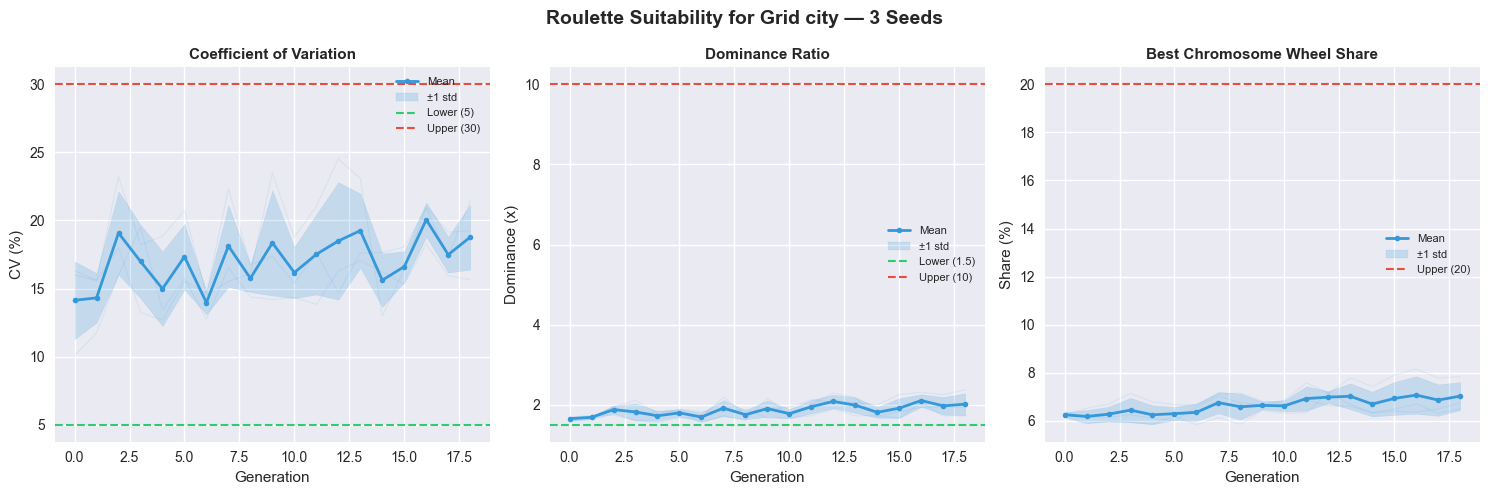

In [40]:
plot_parent_selection_stats(evolution_stats=evolution_stats, city_name=city_name)

#### **Coefficient of Variance**
Checks the value of the `std/mean`. If this value is too small (<5%) then the fitness values are too similar and then if this is too large (>30%) then one solution might be dominating the solution.

**Results**
* Grid City - the mean values sit consistently around 15 which is within the 5-30% range. There is a range of varaince across the seeds as well which means roulette selection has meaningful selection.

#### **Dominance**
Checks the value of `max/min` for the fitness value. If the value is too small (<1.5) then the results are too similar and if the value is too large (>10) the best solution is significantly better than the worse.

**Results**
* Grid City - the mean value for this metric sits just above the 1.5 multiplier threshold.

#### **Best Share**
This value also checks how much the best chromosome makes up of the wheel, `max/total` for the inverse fitness value.

**Results**
* Grid City - the mean value sits around 6% which is well below the 20% meaning the best chromosome never dominates the roulette wheel, meaning the weaker solutions get a chance to be selected.


### TODO: do this for the other cities.

## **Survivor Selection**
* Plot the proportion of parents vs children when using elite selection.
* Compare the best score across parent and child to see if there's any improvement.
* Compare the number of passthrough parents - this might also need looking at in the hyperparameters later.
* Try both approaches with large number of evolutions - does the child approach reach the same result but just with more evolutions?

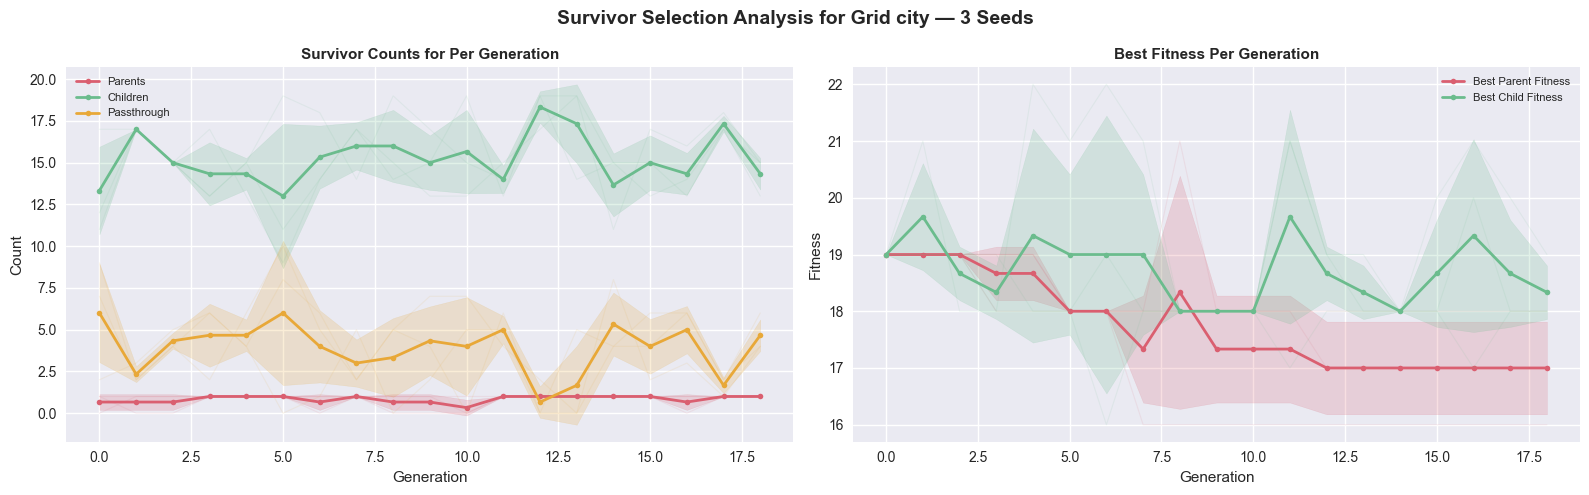

In [47]:
plot_survivor_selection(evolution_stats, city_name)

### TODO: do for the other survivor selection approaches.

### Convergence Criteria
* Adding in the fitness plateau
* Run lots of evolutions and map the critieria across time.
* Make sure to do this across all cities.
* Add in the time tracking to monitor across this as well.

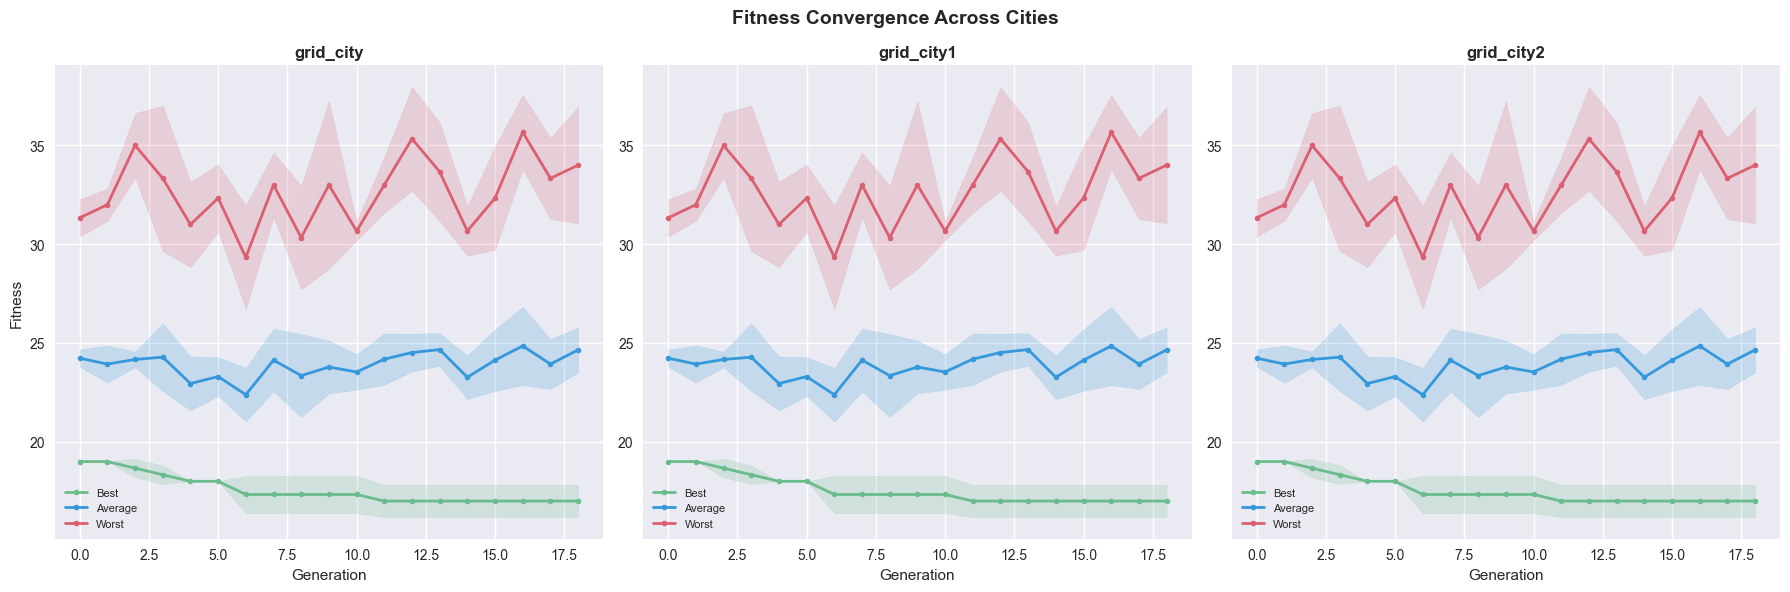

In [ ]:
plot_covergence({
    city_name: evolution_stats,
    # TODO: next city
    # TODO: next city
})

## TODO: need to think about time and how increase the number of evolutions improves the final value.

### Parameter Tuning
Do all of the below for all the cities:
* Crossover probability threshold: `[0, 0.2, 0.4, 0.6, 0.8, 1]` - see how the congestion and path lenghts vary.
* Mutation probability threshold: `[0, 0.2, 0.4, 0.6, 0.8, 1]` - see how the congestion and path lenghts vary (especially important for bottleneck).
* Population Size: `[1, 5, 10, 20, 50, 100]` - showing congestion values vs runtime.
* Random Seed - run a large amount of results to show they are similar (and not seed sensitive).
* Epsilon: `[0, 0.2, 0.4, 0.6, 0.8, 1]` - try different values looking at congestion score performance, convergence speed and variance across seeds.


In [ ]:
hyperparams = hyper_params = {
    "crossover": 0.8,
    "mutation": 0.05,
    "epsilon": 0.2,
    "max_evolutions": 20
}